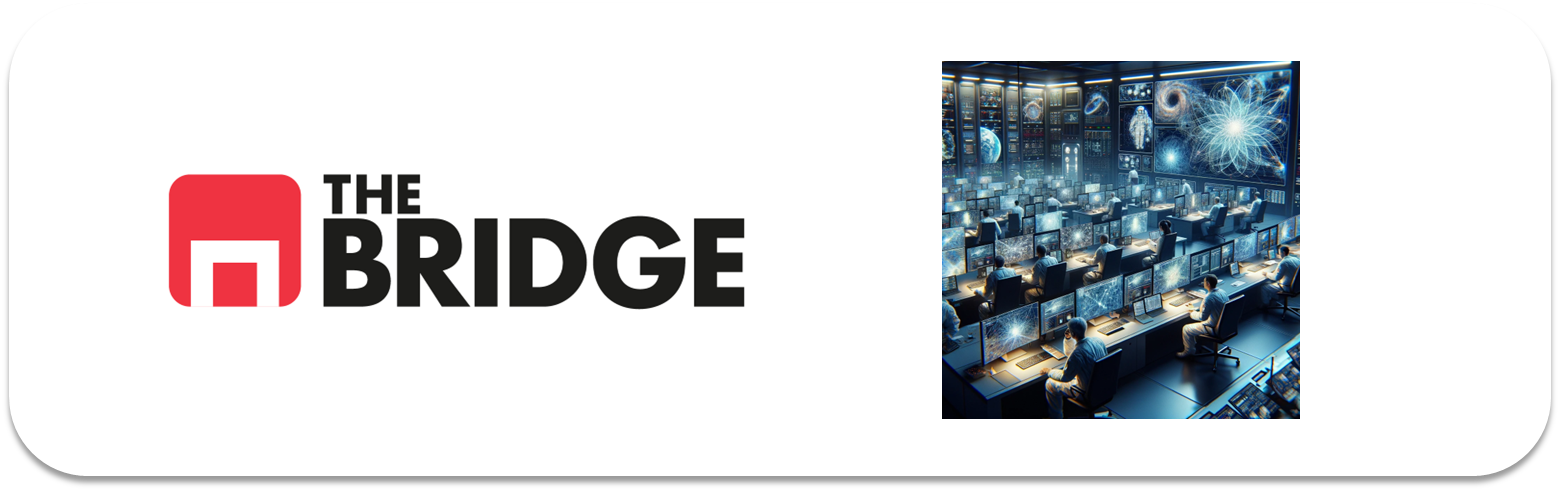

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

2026-04-08 16:31:54.112450: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [2]:
def load_images(directories, img_size=32):
    X, y = [], []
    for directory in directories:
        for filename in os.listdir(directory):
            if filename.endswith('.jpg') or filename.endswith('.png'):
                img = cv2.imread(os.path.join(directory, filename))
                if img is not None:
                    img = cv2.resize(img, (img_size, img_size))
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    X.append(img)
                    label = 1 if 'dog' in filename.lower() else 0  # 1=dog, 0=cat
                    y.append(label)
    return np.array(X), np.array(y)

train_dirs = [
    'data/github_train_0',
    'data/github_train_1',
    'data/github_train_2',
    'data/github_train_3'
]

test_dir = ['data/github_test']

X_train, y_train = load_images(train_dirs)
X_test, y_test = load_images(test_dir)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (4000, 32, 32, 3), Test: (1000, 32, 32, 3)


Train — Dogs: 2000, Cats: 2000
Test  — Dogs: 500, Cats: 500


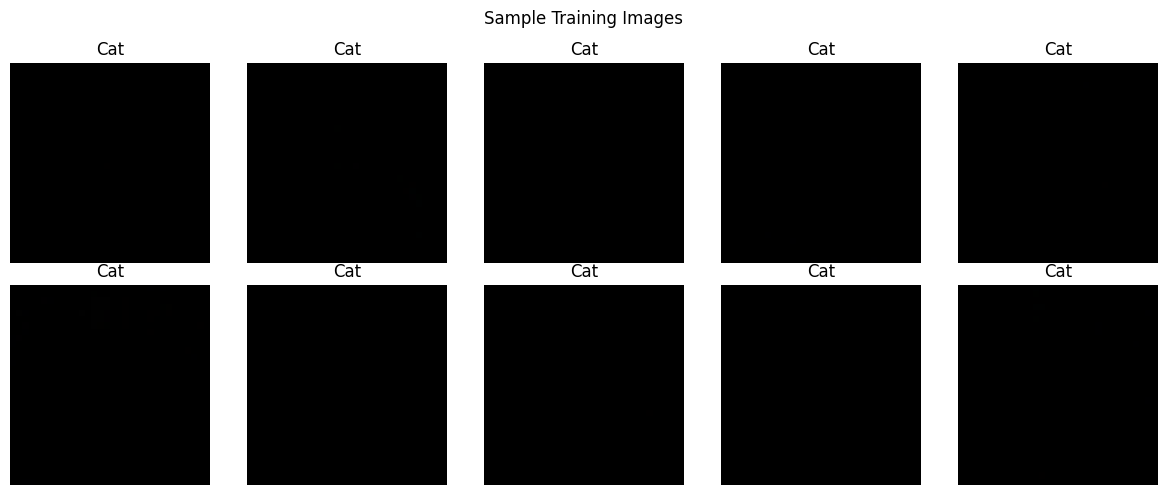

In [4]:

X_train = X_train / 255.0
X_test = X_test / 255.0


print(f"Train — Dogs: {y_train.sum()}, Cats: {(y_train==0).sum()}")
print(f"Test  — Dogs: {y_test.sum()}, Cats: {(y_test==0).sum()}")


fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title("Dog" if y_train[i] == 1 else "Cat")
    ax.axis('off')
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show();

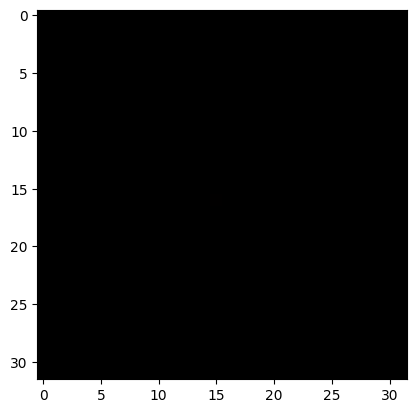

0.00392156862745098 0.0


In [5]:
plt.imshow(X_train[0])
plt.show()
print(X_train[0].max(), X_train[0].min())

In [6]:
# Check a sample filename and path
sample_dir = 'data/github_train_0'
files = os.listdir(sample_dir)
print(files[:5])
print(f"Total files: {len(files)}")

['cat.3406.jpg', 'cat.3374.jpg', 'cat.1205.jpg', 'cat.3412.jpg', 'cat.985.jpg']
Total files: 1000


In [7]:
sample_path = os.path.join(sample_dir, files[0])
print(sample_path)
img = cv2.imread(sample_path)
print(img)

data/github_train_0/cat.3406.jpg
[[[ 89 135 146]
  [106 152 163]
  [110 159 169]
  ...
  [ 18  26  33]
  [ 18  26  33]
  [ 18  26  33]]

 [[ 56 104 116]
  [ 69 117 129]
  [ 72 122 134]
  ...
  [ 18  26  33]
  [ 18  26  33]
  [ 18  26  33]]

 [[ 58 108 126]
  [ 63 113 131]
  [ 62 114 130]
  ...
  [ 18  26  33]
  [ 18  26  33]
  [ 18  26  33]]

 ...

 [[216 213 215]
  [216 213 215]
  [216 213 215]
  ...
  [ 60  63  68]
  [ 59  62  67]
  [ 58  61  66]]

 [[216 213 215]
  [216 213 215]
  [217 214 216]
  ...
  [ 61  64  69]
  [ 60  63  68]
  [ 59  62  67]]

 [[216 213 215]
  [216 213 215]
  [216 213 215]
  ...
  [ 62  65  70]
  [ 61  64  69]
  [ 60  63  68]]]


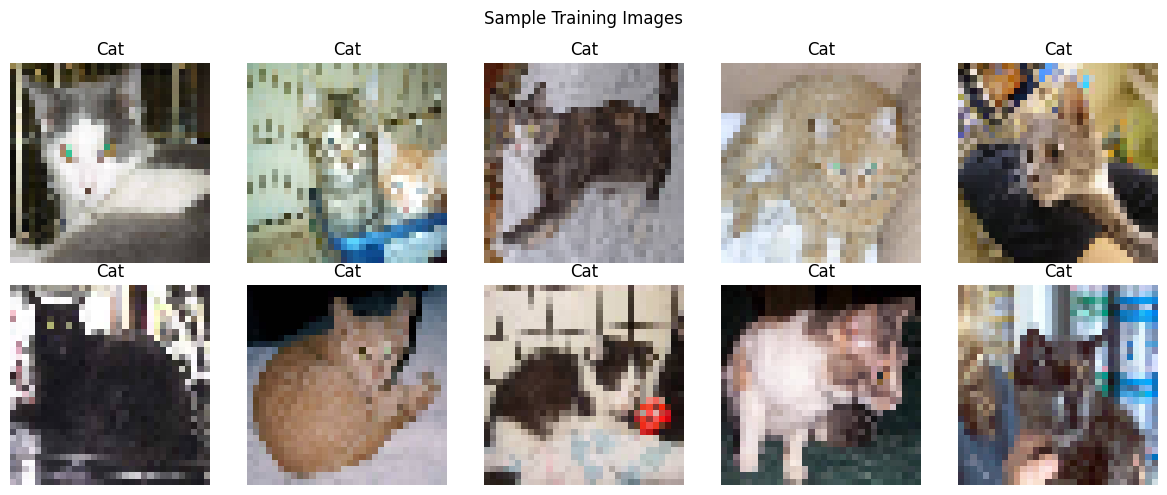

Train — Dogs: 2000, Cats: 2000
Test  — Dogs: 500, Cats: 500


In [ ]:
X_train_raw, y_train = load_images(train_dirs)
X_test_raw, y_test = load_images(test_dir)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_raw[i])
    ax.set_title("Dog" if y_train[i] == 1 else "Cat")
    ax.axis('off')
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

# Now scale
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

print(f"Train — Dogs: {y_train.sum()}, Cats: {(y_train==0).sum()}")
print(f"Test  — Dogs: {y_test.sum()}, Cats: {(y_test==0).sum()}")

In [9]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary: dog or cat
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/Users/radc/Documents/DS-Online/.envs/ds_312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 543,937 (2.07 MB)

 Trainable params: 543,937 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.6153 - loss: 0.6733 - val_accuracy: 0.0000e+00 - val_loss: 0.8164
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6406 - loss: 0.6309 - val_accuracy: 0.1900 - val_loss: 0.8863
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.6791 - loss: 0.5982 - val_accuracy: 0.4525 - val_loss: 0.7794
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7016 - loss: 0.5835 - val_accuracy: 0.5088 - val_loss: 0.7481
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7259 - loss: 0.5563 - val_accuracy: 0.8850 - val_loss: 0.4719
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7281 - loss: 0.5525 - val_accuracy: 0.7513 - val_loss: 0.5364
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7303 - loss: 0.5341 - val_accuracy: 0.6313 - val_loss: 0.6676
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7406 - loss: 0.5153 - val_

In [11]:
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train, random_state=42)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7066 - loss: 0.5717 - val_accuracy: 0.7262 - val_loss: 0.5555
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7138 - loss: 0.5604 - val_accuracy: 0.7250 - val_loss: 0.5468
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.7312 - loss: 0.5427 - val_accuracy: 0.7262 - val_loss: 0.5399
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.7372 - loss: 0.5314 - val_accuracy: 0.7538 - val_loss: 0.5255
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7381 - loss: 0.5247 - val_accuracy: 0.7462 - val_loss: 0.5202
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.7550 - loss: 0.5030 - val_accuracy: 0.7325 - val_loss: 0.5218
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7594 - loss: 0.4891 - val_accuracy: 0.7625 - val_loss: 0.5024
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.7703 - loss: 0.4710 - val_accu

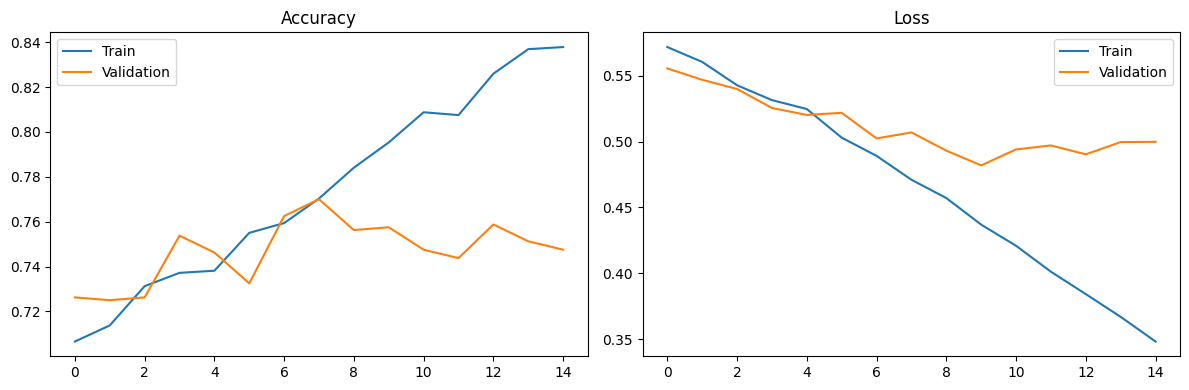

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7560 - loss: 0.5061
Test Loss: 0.5061 | Test Accuracy: 0.7560
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

         Cat       0.76      0.74      0.75       500
         Dog       0.75      0.77      0.76       500

    accuracy                           0.76      1000
   macro avg       0.76      0.76      0.76      1000
weighted avg       0.76      0.76      0.76      1000



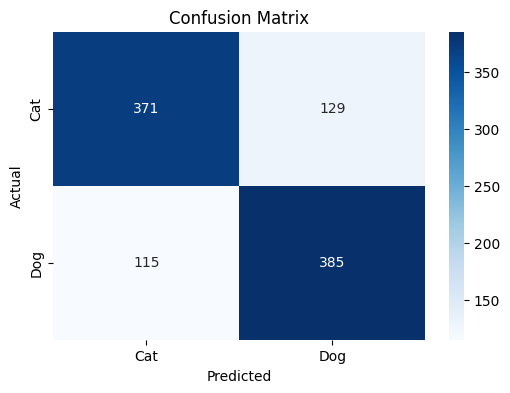

In [13]:

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f} | Test Accuracy: {accuracy:.4f}")

y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=['Cat', 'Dog']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat','Dog'], yticklabels=['Cat','Dog'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [14]:
y_pred_proba_flat = y_pred_proba.flatten()

misclassified = np.where(y_pred != y_test)[0]

wrong_cats = [i for i in misclassified if y_test[i] == 0]  # cats classified as dogs
wrong_dogs = [i for i in misclassified if y_test[i] == 1]  # dogs classified as cats

wrong_cats_sorted = sorted(wrong_cats, key=lambda i: y_pred_proba_flat[i], reverse=True)
wrong_dogs_sorted = sorted(wrong_dogs, key=lambda i: y_pred_proba_flat[i], reverse=False)

n_cats = max(1, int(len(wrong_cats_sorted) * 0.1))
n_dogs = max(1, int(len(wrong_dogs_sorted) * 0.1))

hardest_cats = wrong_cats_sorted[:n_cats]
hardest_dogs = wrong_dogs_sorted[:n_dogs]

print(f"Hardest cats (classified as dogs): {len(hardest_cats)}")
print(f"Hardest dogs (classified as cats): {len(hardest_dogs)}")

Hardest cats (classified as dogs): 12
Hardest dogs (classified as cats): 11


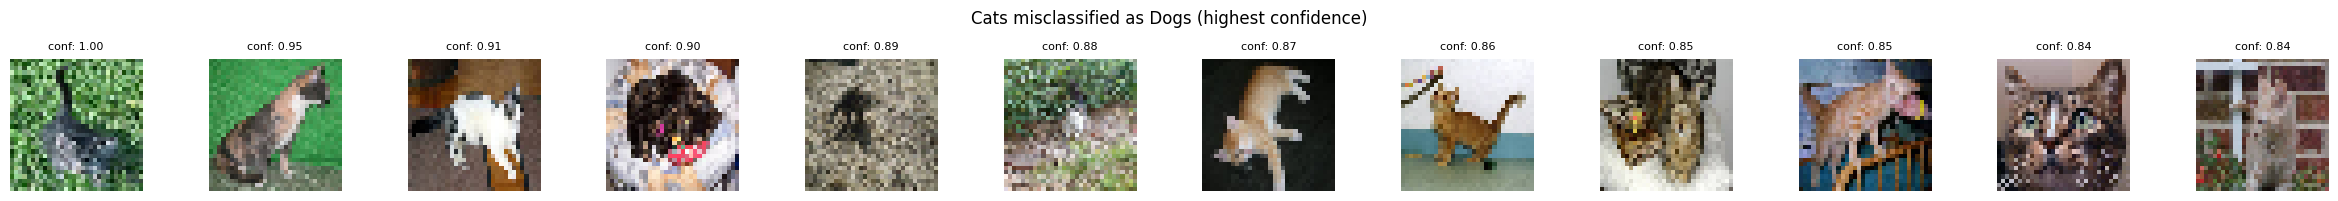

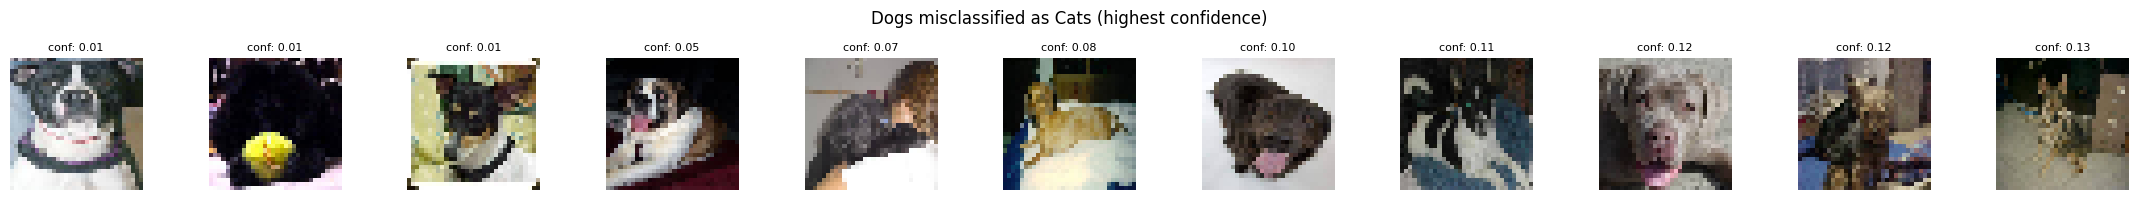

In [15]:
def plot_hardest(indexes, true_label, title, X, proba):
    n = len(indexes)
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    if n == 1:
        axes = [axes]
    for ax, i in zip(axes, indexes):
        ax.imshow(X[i])
        ax.set_title(f"conf: {proba[i]:.2f}", fontsize=8)
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_hardest(hardest_cats, 0, "Cats misclassified as Dogs (highest confidence)", X_test, y_pred_proba_flat)
plot_hardest(hardest_dogs, 1, "Dogs misclassified as Cats (highest confidence)", X_test, y_pred_proba_flat)